In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns


In [ ]:
image_path = r'D:\PythonProject1\Intern\Images\img111.png'
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)
_, thresh = cv2.threshold(gray_image, 240, 245, cv2.THRESH_BINARY_INV)
canny = cv2.Canny(thresh,50,150)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(canny, cmap='gray')
plt.show()

In [ ]:
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
contour_img = image.copy()
cv2.drawContours(contour_img, valid_contours, -1, (0, 255, 0), 3)


In [ ]:
isolated_pieces_list = []  
count=0
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    rgb_piece = cv2.cvtColor(isolated_piece, cv2.COLOR_BGR2RGB)
    isolated_pieces_list.append(rgb_piece)
    count += 1
    plt.imshow(rgb_piece)
    plt.show()
    

In [ ]:
cc=0
for i in isolated_pieces_list:
    if count==cc:
        break
    else:
        top,bottom,left,right=10,10,10,10
        padding_color = [0, 0, 0]
        vertical = cv2.copyMakeBorder(i,0, 0,left,right,borderType=cv2.BORDER_CONSTANT,value=padding_color)
        horizontal=cv2.copyMakeBorder(i,top,bottom,0,0,borderType=cv2.BORDER_CONSTANT,value=padding_color)

        
        cc+=1
        
        plt.imshow(vertical)

        plt.show()
        plt.imshow(horizontal)

        plt.show()

                


In [ ]:
img = isolated_pieces_list[0]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
y_indices, x_indices = np.where(thresh == 255)
if len(y_indices) > 0:
    highest_pixel_idx = np.argmin(y_indices)
    peak_x = x_indices[highest_pixel_idx]
    peak_y = y_indices[highest_pixel_idx]
    output_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
    cv2.circle(output_img, (peak_x, peak_y), 2, (0, 0, 255), -1)
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.show()

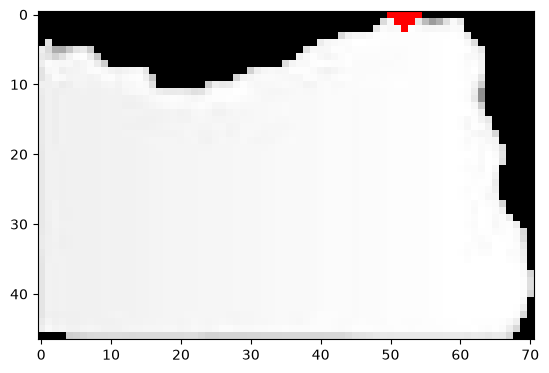

In [ ]:
import cv2
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

img = isolated_pieces_list[0].copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
_, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
edge_profile = np.array([np.where(thresh[:, col] == 255)[0][0] if 255 in thresh[:, col] else thresh.shape[0] for col in range(thresh.shape[1])])
signal = -edge_profile
peaks, _ = find_peaks(signal, distance=len(signal)) # distance forces it to find the single highest global peak
if len(peaks) > 0:
    peak_x = peaks[0]
    peak_y = edge_profile[peak_x]
    output_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
    cv2.circle(output_img, (peak_x, peak_y), 2, (0, 0, 255), -1)

    
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.show()